
 ***Описательная статистика***
       Итого_активы     Выручка  Чистая_прибыль  Внеоборотные_активы  \
count       1000.00     1000.00         1000.00              1000.00   
mean        9830.29    10006.74          118.10              4016.02   
std        80062.51   107836.23         3088.09             24999.81   
min            0.00        0.00       -32644.00                 0.00   
25%            0.00        0.00            0.00                 0.00   
50%            0.00        0.00            0.00                 0.00   
75%          238.50      390.25            0.00                 0.00   
max      2172844.00  3111601.00        59175.00            521931.00   

       Оборотные_активы     Запасы   Дебиторка    Капитал  \
count           1000.00    1000.00     1000.00    1000.00   
mean            5814.27    2581.34     2851.90    2438.67   
std            59018.53   18329.96    39184.92   15722.74   
min                0.00       0.00        0.00  -39077.00   
25%           

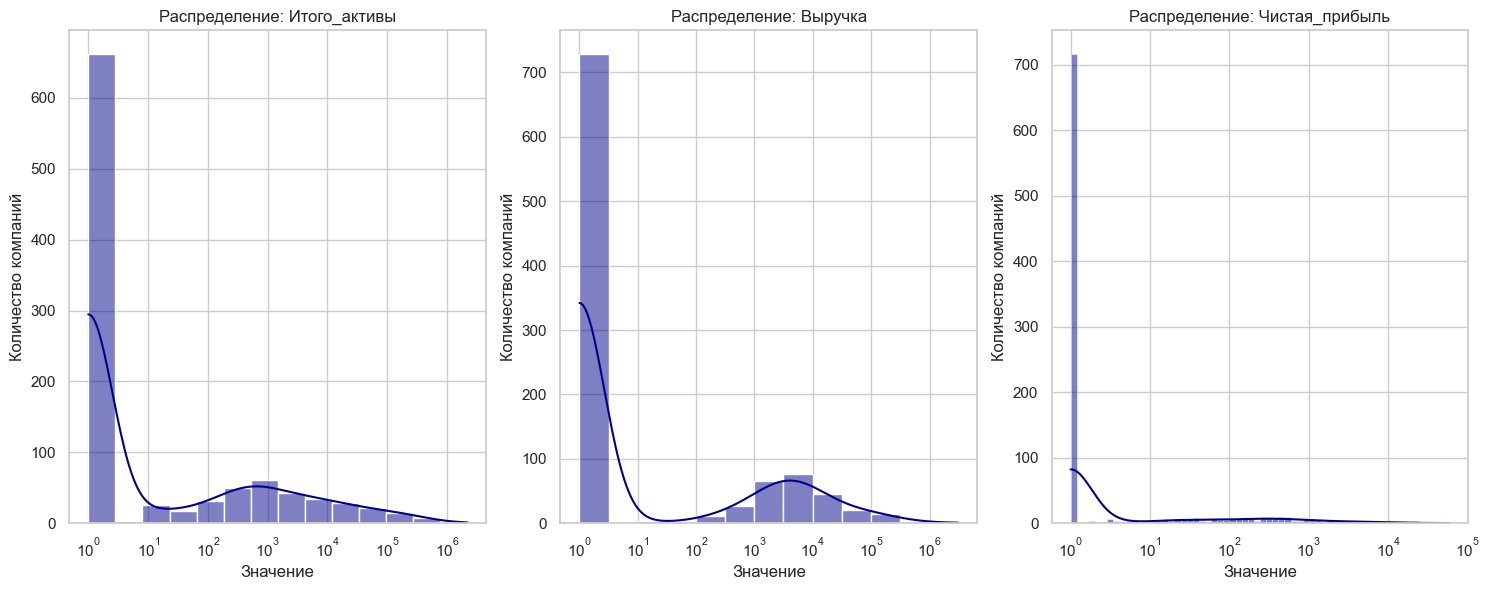

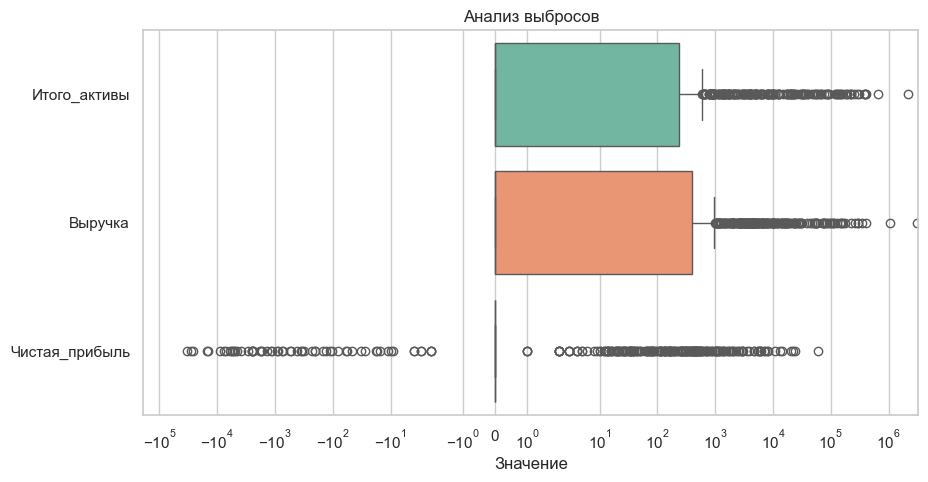

***Выводы по аномлиям***
Присутсвуют компании, которые кратно крупнее среднего значения по выборке


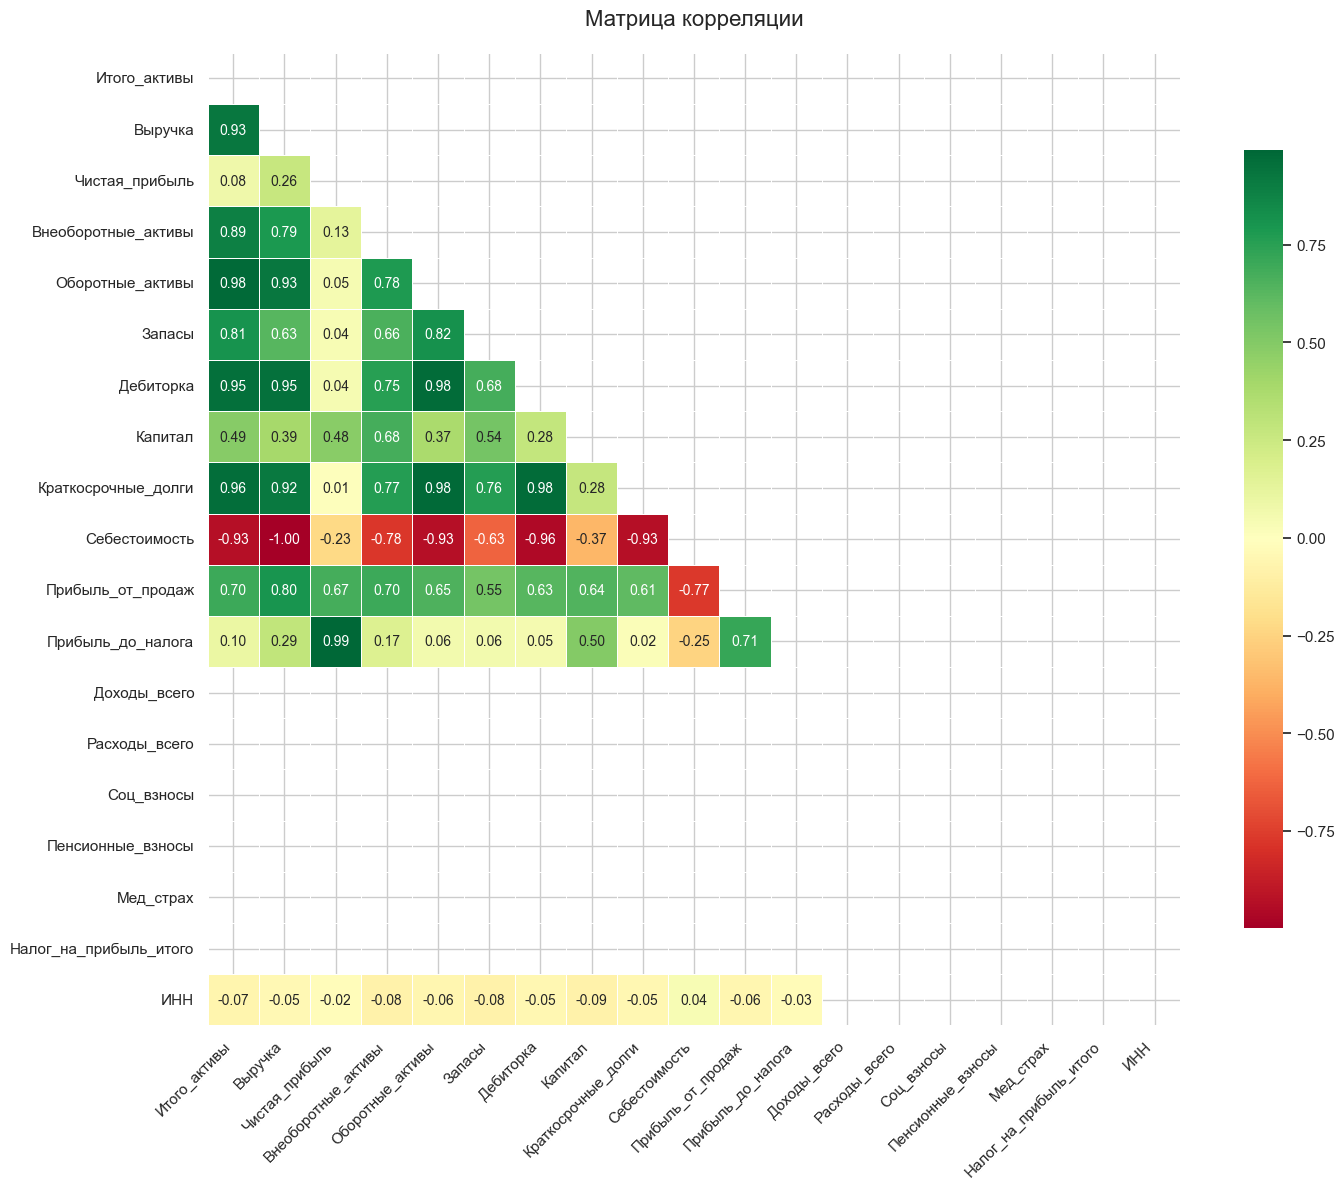

***Выводы по корреляции***
1. Выручка и Себестоимость: при росте объемов продаж пропорционально растут и затраты
2. Итого активы и Внеоборотные/Оборотные активы: математическая корреляция, т.к. Итого активы — это сумма внеоборотных и оборотных активов
3. Прибыль до налога и Чистая прибыль: аналогично математическая корреляция прямая зависимость показателей


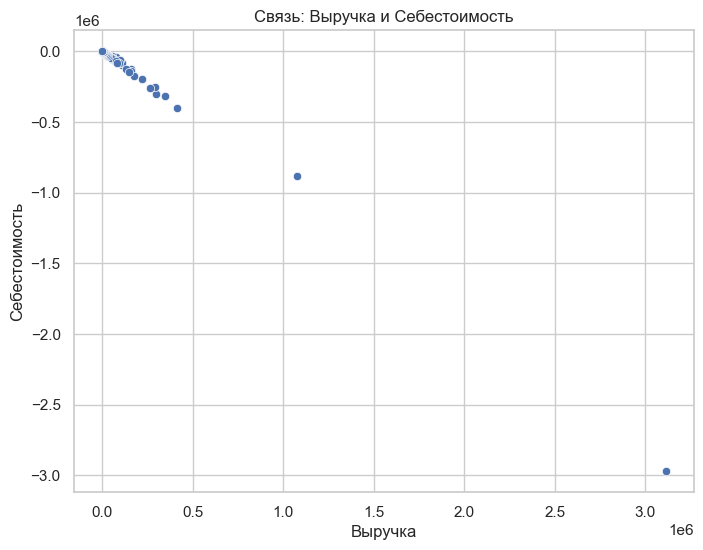


***Выводы***
1.Кратный разрыв между медианой и максимальными значениями показателях Выручки говорит о том, что средние значения смещены из-за нескольких гигантов.
2.Облако точек на графике «Выручка vs Себестоимость» вытянуто в узкую прямую линию. Выпадающие значения являются аномалиями, это могло быть при налоговых манипуляциях.


In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

def analyze_rfsd_final():
    # 1. Загрузка данных
    dataset = load_dataset('irlspbru/RFSD', split='train', streaming=True)
    # Берем 1000 строк
    df = pd.DataFrame(list(dataset.take(1000)))

    # 2. Найдем колонки по кодам ОКУД и сделаем читаемыми
    target_map = {
    'line_1600': 'Итого_активы',
    'line_2110': 'Выручка',
    'line_2400': 'Чистая_прибыль',
    'line_1100': 'Внеоборотные_активы',
    'line_1200': 'Оборотные_активы',
    'line_1210': 'Запасы',
    'line_1230': 'Дебиторка',
    'line_1300': 'Капитал',
    'line_1500': 'Краткосрочные_долги',
    'line_2120': 'Себестоимость',
    'line_2200': 'Прибыль_от_продаж',
    'line_2300': 'Прибыль_до_налога',
    'line_6100': 'Доходы_всего',
    'line_6200': 'Расходы_всего',
    'line_6320': 'Соц_взносы',
    'line_6321': 'Пенсионные_взносы',
    'line_6322': 'Мед_страх',
    'line_6400': 'Налог_на_прибыль_итого',
    'name': 'Название_компании',
    'inn': 'ИНН'
    }

    found_cols = {}
    for code, name in target_map.items():
        match = [c for c in df.columns if code in str(c)]
        if match:
            found_cols[match[0]] = name

    # Переименуем найденные колонки
    df.rename(columns=found_cols, inplace=True)
    names = list(found_cols.values())

    #Преобразуем в числа, если вдруг не число
    for col in names:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Создаем DF для анализа
    analysis_df = df[names].fillna(0)

    if analysis_df.empty or len(analysis_df.columns) < 2:
        print("Ошибка: Финансовые колонки не найдены. Проверьте структуру данных.")
        return

    # Ограничим основной DF до 20 колонок
    df_to_save = analysis_df.iloc[:, :20]
    df_to_save.to_csv("rfsd_data.csv", index=False)

    sns.set_theme(style="whitegrid")
    
    """Начинаем анализ
    Задание 1. Выведите описательную статистику для датасета"""
    print("\n ***Описательная статистика***")
    print(analysis_df.describe().round(2))
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.size'] = 10

    """Задание 2. Постройте гистограммы для трех колонок, которые, на ваш взгляд,
    могут содержать полезную информацию. Выясните, есть ли в этих
    колонках выбросы и аномалии (значения, которые сильно
    отличаются от остальных значений или кажутся
    странными/некорректными).
    
    
    Построим гистограммы для трех колонок. Для анализа выберем колонки:
    Активы, Выручка и Прибыль
    как основные показатели фин.результата компании
    """
    
    
    
    """
    Логарифмическая гистограмма
    Позволяет увидеть и малый, и средний, и крупный бизнес на одном графике
    """
    plt.figure(figsize=(15, 6))
    for i, col in enumerate(analysis_df.columns[:3]):
        plt.subplot(1, 3, i+1)
        #+1, чтобы уйти от log(0)
        sns.histplot(analysis_df[col] + 1, kde=True, log_scale=True, color='darkblue')
        plt.title(f'Распределение: {col}')
        plt.xlabel('Значение')
        plt.ylabel('Количество компаний')
    plt.tight_layout()
    plt.show()


    """
    Ящик с усами — для поиска аномалий/выбросов
    """
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=analysis_df[analysis_df.columns[:3]], orient='h', palette="Set2")
    plt.xscale('symlog')
    plt.title('Анализ выбросов')
    plt.xlabel('Значение')
    plt.show()

    print(f'***Выводы по аномлиям***')
    print(f'Присутсвуют компании, которые кратно крупнее среднего значения по выборке')
    
   
   
    """
    Задание 3. Вычислите и визуализируйте матрицу корреляции между всеми 20
    колонками. Между какими колонками имеется высокая
    корреляция? Что означает эта высокая корреляция и в чем может
    быть ее причина?
    """    
   #Преобразуем все колонки в числа.
    for col in df_to_save.columns:
        analysis_df[col] = analysis_df[col].apply(lambda x: x.get('value') if isinstance(x, dict) else x)
        analysis_df[col] = analysis_df[col].apply(lambda x: x[0] if isinstance(x, list) else x)

    #Удаляем колонки, которые полностью пустые (например, текстовые названия компаний)
    #и заполняем оставшиеся пропуски нулями
    matrix_df = analysis_df.dropna(axis=1, how='all').fillna(0)

    #Визуализация матрицы корреляции
    plt.figure(figsize=(15, 12))
    correlation = analysis_df.corr(numeric_only=True)

    #Скроем верхний треугольник для наглядности
    mask = np.triu(np.ones_like(correlation, dtype=bool))
    sns.heatmap(correlation,
                mask = mask, 
                annot=True, 
                fmt=".2f", 
                cmap='RdYlGn', 
                center=0,
                square=True, 
                linewidths=.5, 
                cbar_kws={"shrink": .8})

    plt.title("Матрица корреляции", fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f'***Выводы по корреляции***')
    print(f'1. Выручка и Себестоимость: при росте объемов продаж пропорционально растут и затраты')
    print(f'2. Итого активы и Внеоборотные/Оборотные активы: математическая корреляция, т.к. Итого активы — это сумма внеоборотных и оборотных активов')
    print(f'3. Прибыль до налога и Чистая прибыль: аналогично математическая корреляция прямая зависимость показателей')
    
    
    """
    Задание 4. Постройте диаграмму рассеивания (scatter plot) между коррелирующими колонками
    """ 
    if len(names) >= 2:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=analysis_df, x='Выручка', y='Себестоимость')
        plt.title(f"Связь: Выручка и Себестоимость")
        plt.show()
    
    
    """
    Задание 5. Сделайте как минимум один вывод исходя из
    описательной статистики, гистограмм, матрицы корреляции, диаграммы рассеивания.
    """
    print("\n***Выводы***")
    print(f"1.Кратный разрыв между медианой и максимальными значениями показателях Выручки говорит о том, что средние значения смещены из-за нескольких гигантов.")
    print(f"2.Облако точек на графике «Выручка vs Себестоимость» вытянуто в узкую прямую линию. Выпадающие значения являются аномалиями, это могло быть при налоговых манипуляциях.")
    
if __name__ == "__main__":
    analyze_rfsd_final()